# Step 3.1 — Modeling: Random Forest on the six global features
## Dataset B — PlantVillage (raw, disease classification)

This notebook trains **one model** — a **Random Forest with balanced class weights** — on the **exact six global tabular features the Step 3.1 LogReg used**: `file_size_kb`, `brightness`, `mean_R`, `mean_G`, `mean_B`, `green_frac`. It is written to **stand alone**: it produces the forest's **validation macro-F1, per-class recall, and confusion matrix**, saves the trained model, and stops there.

**Why this notebook exists (it is a *documentation floor*, not a rival model).** The baseline notebook already ran a **Logistic Regression** on these six whole-image summaries and it landed near the dummy floor — the direct confirmation of Deliverable 1's Figures 3–5 that the features are redundant and the disease signal is **not linearly separable** from global colour. A Random Forest is a **non-linear** ensemble. Running it on the **same six features** answers the natural follow-up: *is the limitation the model, or the features?* If a non-linear model on the identical inputs also lands near the floor, the case is airtight — the six global features simply lack the (local, lesion-scale) signal, which is the empirical argument for the CNN.

> This is the **six-feature sibling** to the richer classical baseline `Step3_1_PlantVillage_RandomForest` (RGB/HSV histograms + GLCM). Keep whichever the report needs; this one exists specifically to hold the **features fixed to the LogReg's** and vary only the model.

**What it inherits from Deliverable 1 (so it lines up with the other models):**
- the raw **color** PlantVillage images (38 classes, 54,305 images);
- the **file-level, stratified, leakage-free 70/15/15 split** — loaded from the same shared CSVs;
- **class weights** for the ~36:1 imbalance, passed to the forest as `class_weight="balanced"`;
- the **identical six-feature definition** and (by default) the **same cached validation features** the LogReg scored on.

**Test-set discipline.** The held-out **test set is loaded but never touched** — sealed for Deliverable 2. Every score here is on the **validation** set.

Each cell carries a short **why / how it fits** note, paths are auto-discovered, and the feature step is cached so re-runs are quick.

> **Runtime:** no GPU needed. Trees are cheap on six features; the one-off feature extraction is cached.

## Colab setup — run this first

On **Google Colab** the dataset is pulled from Kaggle, which needs your Kaggle API key. We use **Colab Secrets** so the key never lives in the notebook (same setup as the other notebooks):

1. Open your `kaggle.json` (it reads `{"username": "...", "key": "..."}`).
2. In the left sidebar, click the **key icon (Secrets)** → **Add new secret** twice, each with **Notebook access** on: `KAGGLE_USERNAME` and `KAGGLE_KEY`.
3. Run the cell below, then **Runtime ▸ Run all**.

*(Run locally, this cell does nothing and the notebook uses your local `~/.kaggle/kaggle.json` instead.)*

In [ ]:
# Colab: load Kaggle credentials from Colab Secrets. Harmless when run locally.
import os
try:
    from google.colab import userdata
    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"]      = userdata.get("KAGGLE_KEY")
    print("Kaggle credentials loaded from Colab Secrets.")
except ModuleNotFoundError:
    pass  # not on Colab - falls back to local ~/.kaggle/kaggle.json

Kaggle credentials loaded from Colab Secrets.


## 0. Setup and configuration

Imports, one fixed seed, the shared paths, and a single config block. The **paths matter**: the split CSVs (and the LogReg's cached `tabular_val.csv`) live in the baseline folder `step3_baseline/`, so this notebook reads the *same* validation features the LogReg scored on. RF-specific artifacts go in their own folder `step3_rf_global6/`.

**Why run it:** a Colab kernel forgets every variable on restart; the fixed seed keeps the split and the forest reproducible.

**How it fits:** it locks this notebook onto the same data, split, and six-feature definition as the LogReg — so the only difference is the model.

In [ ]:
# Imports, seed, shared paths, and the run configuration
from pathlib import Path
from collections import deque
import os, time, random, json
import numpy as np, pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, recall_score, accuracy_score,
                             confusion_matrix, classification_report)
import joblib

sns.set_theme()
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# ---- paths ----------------------------------------------------------------
# SPLIT_DIR is SHARED (same train/val/test + the LogReg's cached tabular features);
# the forest's own artifacts go in RF_DIR.
BASE       = Path.home() / "plant_recognition"
PV_DIR     = BASE / "plantvillage"
SPLIT_DIR  = BASE / "step3_baseline"; SPLIT_DIR.mkdir(parents=True, exist_ok=True)
RF_DIR     = BASE / "step3_rf_global6"; RF_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_CSV  = {s: SPLIT_DIR / f"split_{s}.csv" for s in ("train", "val", "test")}
VAL_TAB_CSV = SPLIT_DIR / "tabular_val.csv"   # reused from the baseline LogReg if present
IMG_EXTS   = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff"}

# ---- the six global features (IDENTICAL to the baseline LogReg) ------------
TAB_COLS = ["file_size_kb", "brightness", "mean_R", "mean_G", "mean_B", "green_frac"]

# ---- run configuration (everything tunable in one place) ------------------
SPLIT             = (0.70, 0.15, 0.15)   # train / val / test  (Deliverable 1, Section 7.3)
N_ESTIMATORS      = 300                   # trees in the forest
RF_TRAIN_PER_CLASS = None                 # None = fit on the FULL training split (gives the forest its best shot).
                                          # Set to 300 to match the LogReg's per-class train sample exactly.

# Smoke test: flip to True for a quick end-to-end dry run (never cached).
SMOKE_TEST      = False
SMOKE_PER_CLASS = 60

_tag = "full" if RF_TRAIN_PER_CLASS is None else f"cap{RF_TRAIN_PER_CLASS}"
print("Config: features=6 (global tabular, LogReg-matched), "
      f"N_ESTIMATORS={N_ESTIMATORS}, RF_TRAIN_PER_CLASS={RF_TRAIN_PER_CLASS}, SMOKE_TEST={SMOKE_TEST}")

Config: features=6 (global tabular, LogReg-matched), N_ESTIMATORS=300, RF_TRAIN_PER_CLASS=None, SMOKE_TEST=False


## 1. Download the raw dataset (skips if already present)

Fetches PlantVillage from Kaggle and **skips if it is already on disk** — so if you ran another notebook in this session it is reused instantly.

**Why run it:** we need the raw images locally to compute the features; the skip-guard avoids re-downloading gigabytes.

**How it fits:** the same untouched source as every other notebook — clean, shared provenance.

In [ ]:
# Download raw PlantVillage from Kaggle (skips if PV_DIR is non-empty; needs kaggle.json)
if not PV_DIR.exists() or not any(PV_DIR.iterdir()):
    from kaggle.api.kaggle_api_extended import KaggleApi
    PV_DIR.mkdir(parents=True, exist_ok=True)
    api = KaggleApi(); api.authenticate()
    api.dataset_download_files("abdallahalidev/plantvillage-dataset",
                               path=str(PV_DIR), unzip=True, quiet=False)
    print("Downloaded to", PV_DIR)
else:
    print("Already present:", PV_DIR)

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset


100%|██████████| 2.04G/2.04G [00:28<00:00, 77.3MB/s]



Downloaded to /root/plant_recognition/plantvillage


## 2. Locate the `color` rendering and confirm the 38 classes

The archive nests `color`, `grayscale` and `segmented` inside a wrapper folder. We locate the **color** copy automatically (same helper as the other notebooks) and confirm the class list and its canonical sorted order.

**Why run it:** hard-coded paths break across machines; auto-discovery does not.

**How it fits:** it pins the exact folder and the sorted class order the integer labels use everywhere.

In [ ]:
# Breadth-first search for the 'color' folder, then list the classes (sorted = canonical label order)
def locate(root, names, max_depth=4):
    q = deque([(root, 0)])
    while q:
        d, depth = q.popleft()
        if d.is_dir() and d.name.lower() in names:
            return d
        if d.is_dir() and depth < max_depth:
            for c in sorted(d.iterdir()):
                if c.is_dir():
                    q.append((c, depth + 1))
    return None

COLOR_DIR = locate(PV_DIR, {"color"})
assert COLOR_DIR is not None, "Could not find a 'color' folder under PV_DIR - check the path."
class_names = sorted([d.name for d in COLOR_DIR.iterdir() if d.is_dir()])
name2idx    = {n: i for i, n in enumerate(class_names)}       # label -> integer index (used everywhere)
n_classes   = len(class_names)
print("color dir:", COLOR_DIR)
print(f"classes: {n_classes}")
assert n_classes == 38, f"expected 38 classes, found {n_classes}"
print("first / last class:", class_names[0], "/", class_names[-1])

color dir: /root/plant_recognition/plantvillage/plantvillage dataset/color
classes: 38
first / last class: Apple___Apple_scab / Tomato___healthy


## 3. The stratified, leakage-free 70/15/15 split (file level)

Loaded from the **shared** split CSVs written by the baseline notebook, so this forest reads the *identical* train/val/test files as every other model. If the CSVs are absent, it rebuilds the same split (`train_test_split` twice, stratified) and writes them.

**Why run it:** a matching split is what makes the numbers comparable; rebuilding from the same seed reproduces it exactly if the CSVs are missing.

**How it fits:** identical inputs across models is the whole point of this notebook — same split, same features, only the model differs.

In [ ]:
# Build (or load) the canonical file-level stratified split, then verify it
def enumerate_files(color_dir):
    paths, labels = [], []
    for c in class_names:
        for f in sorted((color_dir / c).iterdir()):
            if f.suffix.lower() in IMG_EXTS:
                paths.append(str(f)); labels.append(c)
    return np.array(paths), np.array(labels)

if all(p.exists() for p in SPLIT_CSV.values()):
    # Reuse the canonical split saved by another notebook / a teammate -> identical splits
    dfs = {s: pd.read_csv(SPLIT_CSV[s]) for s in SPLIT_CSV}
    p_tr,  y_tr  = dfs["train"]["filepath"].values, dfs["train"]["label"].values
    p_val, y_val = dfs["val"]["filepath"].values,   dfs["val"]["label"].values
    p_te,  y_te  = dfs["test"]["filepath"].values,  dfs["test"]["label"].values
    print("Loaded saved split from CSV (canonical, shared).")
else:
    paths, labels = enumerate_files(COLOR_DIR)
    print(f"enumerated {len(paths):,} image files")
    test_frac = SPLIT[2]
    val_frac_of_rest = SPLIT[1] / (SPLIT[0] + SPLIT[1])
    p_tr, p_te, y_tr, y_te = train_test_split(
        paths, labels, test_size=test_frac, stratify=labels, random_state=SEED)
    p_tr, p_val, y_tr, y_val = train_test_split(
        p_tr, y_tr, test_size=val_frac_of_rest, stratify=y_tr, random_state=SEED)
    for s, (pp, yy) in {"train": (p_tr, y_tr), "val": (p_val, y_val), "test": (p_te, y_te)}.items():
        pd.DataFrame({"filepath": pp, "label": yy}).to_csv(SPLIT_CSV[s], index=False)
    print("Built split with train_test_split x2 (stratified) and saved CSVs (now shared).")

# ---- verify: sizes, every class present in each set, and no leakage across sets ----
print(f"\ntrain / val / test : {len(p_tr):,} / {len(p_val):,} / {len(p_te):,}"
      f"  ({len(p_tr)/(len(p_tr)+len(p_val)+len(p_te)):.0%} / "
      f"{len(p_val)/(len(p_tr)+len(p_val)+len(p_te)):.0%} / "
      f"{len(p_te)/(len(p_tr)+len(p_val)+len(p_te)):.0%})")
for nm, yy in [("train", y_tr), ("val", y_val), ("test", y_te)]:
    assert set(yy) == set(class_names), f"{nm} is missing classes!"
s_tr, s_val, s_te = set(p_tr), set(p_val), set(p_te)
assert s_tr.isdisjoint(s_val) and s_tr.isdisjoint(s_te) and s_val.isdisjoint(s_te), "LEAKAGE: sets overlap!"
print("verified: all 38 classes present in each split, and the three sets are disjoint (no leakage).")
print("NOTE: the test set is loaded here but is NOT used again - it is reserved for Deliverable 2.")

enumerated 54,305 image files
Built split with train_test_split x2 (stratified) and saved CSVs (now shared).

train / val / test : 38,013 / 8,146 / 8,146  (70% / 15% / 15%)
verified: all 38 classes present in each split, and the three sets are disjoint (no leakage).
NOTE: the test set is loaded here but is NOT used again - it is reserved for Deliverable 2.


## 4. Class weights from the training split

Weights **inversely proportional to class frequency**, from the **training labels only** (Section 7.7). We print them for reference and pass `class_weight="balanced"` to the forest, which applies the same idea while fitting.

**Why run it:** at ~36:1 the forest would otherwise chase the big Tomato/Orange classes and ignore the rare ones (healthy Potato, 152 images).

**How it fits:** the imbalance remedy the report specified — applied here to the classical model, exactly as for the CNN.

In [ ]:
# Balanced class weights from the FULL training split (for reference + passed to the RF)
yi_tr_full = np.array([name2idx[y] for y in y_tr], dtype="int64")
weights = compute_class_weight("balanced", classes=np.arange(n_classes), y=yi_tr_full)
class_weight = {i: float(w) for i, w in enumerate(weights)}
print("weight range on full train: {:.2f} (most common) ... {:.2f} (rarest)".format(
      min(class_weight.values()), max(class_weight.values())))
top = sorted(class_weight.items(), key=lambda kv: kv[1], reverse=True)[:3]
print("highest-weighted (rarest) classes:", [(class_names[i], round(w, 1)) for i, w in top])
print("The RF is trained with class_weight='balanced', so it recomputes these on the data it is fit on.")

weight range on full train: 0.26 (most common) ... 9.44 (rarest)
highest-weighted (rarest) classes: [('Potato___healthy', 9.4), ('Apple___Cedar_apple_rust', 5.2), ('Peach___healthy', 4.0)]
The RF is trained with class_weight='balanced', so it recomputes these on the data it is fit on.


## 5. The six global features — identical to the LogReg

For each image we compute the **same six whole-image summaries** Deliverable 1 defined and the baseline LogReg used: file size, mean brightness, the three colour-channel means, and the green fraction `G/(R+G+B)`. Nothing is engineered beyond what the LogReg saw — that is deliberate, so the comparison isolates the model.

- **Validation features** are loaded from the LogReg's cached `tabular_val.csv` when present, guaranteeing the forest is scored on the *identical* rows.
- **Training features** are computed for the training split (full by default, or capped per class via `RF_TRAIN_PER_CLASS`) and cached in the RF folder so re-runs are instant.

**Note on scaling:** unlike the LogReg (which used `StandardScaler`), the forest needs **no scaling** — trees split on thresholds, so any monotonic rescaling of a feature is irrelevant. We feed the raw six columns.

**Why run it:** the forest needs a fixed-length numeric vector per image; these six numbers are that vector.

**How it fits:** it is the representation — held fixed to the LogReg's — that the Random Forest is trained and scored on.

In [ ]:
# Compute (or load) the six global features for train + val; cache so re-runs are instant.
def cap_per_class(paths, labels, cap, seed=SEED):
    rng = random.Random(seed); by = {}
    for p, l in zip(paths, labels): by.setdefault(l, []).append(p)
    op, ol = [], []
    for l, ps in by.items():
        sel = ps if len(ps) <= cap else rng.sample(ps, cap)
        op += sel; ol += [l] * len(sel)
    idx = np.arange(len(op)); rng.shuffle(idx)
    op, ol = np.array(op), np.array(ol)
    return op[idx], ol[idx]

def image_tab_features(paths, labels):
    rows = []
    for fp, lab in zip(paths, labels):
        try:
            im = np.asarray(Image.open(fp).convert("RGB")).astype("float64")
            r, g, b = (im[:, :, i].mean() for i in range(3)); br = im[:, :, :3].mean()
            rows.append({"filepath": fp, "label": lab, "file_size_kb": os.path.getsize(fp) / 1024,
                         "brightness": br, "mean_R": r, "mean_G": g, "mean_B": b,
                         "green_frac": g / (r + g + b)})
        except Exception:
            pass
    return pd.DataFrame(rows)

# ---- choose the training rows (full split, per-class cap, or smoke subsample) ----
if SMOKE_TEST:
    ptr_use, ytr_use   = cap_per_class(p_tr, y_tr, SMOKE_PER_CLASS)
    pval_use, yval_use = cap_per_class(p_val, y_val, max(20, SMOKE_PER_CLASS // 3))
    print(f"[SMOKE_TEST] train={len(ptr_use):,}, val={len(pval_use):,} (features not cached)")
else:
    ptr_use, ytr_use   = (p_tr, y_tr) if RF_TRAIN_PER_CLASS is None else cap_per_class(p_tr, y_tr, RF_TRAIN_PER_CLASS)
    pval_use, yval_use = p_val, y_val

TRAIN_TAB_CSV = RF_DIR / f"tabular_train_{_tag}.csv"

# ---- training features: load cache or compute ----
if (not SMOKE_TEST) and TRAIN_TAB_CSV.exists():
    tab_tr = pd.read_csv(TRAIN_TAB_CSV)
    print("Loaded cached TRAIN features:", tab_tr.shape)
else:
    print(f"computing 6 global features for {len(ptr_use):,} train images (one-off)...")
    t0 = time.time(); tab_tr = image_tab_features(ptr_use, ytr_use)
    print(f"  done in {time.time()-t0:.0f}s")
    if not SMOKE_TEST:
        tab_tr.to_csv(TRAIN_TAB_CSV, index=False)

# ---- validation features: reuse the LogReg's cache when present, else compute (and share) ----
if (not SMOKE_TEST) and VAL_TAB_CSV.exists():
    tab_val = pd.read_csv(VAL_TAB_CSV)
    print("Loaded VAL features from the baseline LogReg cache (identical rows):", tab_val.shape)
else:
    print(f"computing 6 global features for {len(pval_use):,} val images (one-off)...")
    t0 = time.time(); tab_val = image_tab_features(pval_use, yval_use)
    print(f"  done in {time.time()-t0:.0f}s")
    if not SMOKE_TEST:
        tab_val.to_csv(VAL_TAB_CSV, index=False)  # written to the shared folder so the LogReg can reuse it too

# ---- assemble matrices (no scaling: trees are threshold-based) ----
Xtr,  ytr  = tab_tr[TAB_COLS].values,  tab_tr["label"].map(name2idx).values
Xval, yval = tab_val[TAB_COLS].values, tab_val["label"].map(name2idx).values
print(f"\nX_train {Xtr.shape}  |  X_val {Xval.shape}  |  {len(TAB_COLS)} features:", TAB_COLS)

computing 6 global features for 38,013 train images (one-off)...
  done in 65s
computing 6 global features for 8,146 val images (one-off)...
  done in 13s

X_train (38013, 6)  |  X_val (8146, 6)  |  6 features: ['file_size_kb', 'brightness', 'mean_R', 'mean_G', 'mean_B', 'green_frac']


## 6. Train the Random Forest

A single `RandomForestClassifier` on the six features, with `class_weight="balanced"` for the imbalance and a fixed seed for reproducibility. On six features this fits in seconds even on the full training split.

**Why run it:** this is the one model the notebook exists to produce and score.

**How it fits:** it is the **non-linear** counterpart to the baseline LogReg — same features, different model — so its validation score, read next to the LogReg's, says whether the ceiling was the model or the features.

In [ ]:
# Fit the forest on the six global features
rf = RandomForestClassifier(n_estimators=N_ESTIMATORS, class_weight="balanced",
                            n_jobs=-1, random_state=SEED)
t0 = time.time(); rf.fit(Xtr, ytr)
print(f"trained {N_ESTIMATORS} trees on {Xtr.shape[0]:,} x {Xtr.shape[1]} features in {time.time()-t0:.1f}s")

trained 300 trees on 38,013 x 6 features in 57.3s


## 7. Evaluate on the validation set

Predict the validation set once, then report the metrics Deliverable 1 committed to — **macro-F1** (not plain accuracy, which flatters an imbalanced model), overall accuracy, and **per-class recall sorted worst-first**, where the imbalance bites.

**Why run it:** macro-F1 on validation is the number the report compares against the LogReg floor and the CNN.

**How it fits:** it places this classical model on the same validation yardstick as every other model in Step 3.1.

In [ ]:
# Predict validation once, then compute the report metrics
pred = rf.predict(Xval)
rf_mf1 = f1_score(yval, pred, average="macro", zero_division=0)
rf_acc = accuracy_score(yval, pred)
print(f"Random Forest (6 global features):  macro-F1 = {rf_mf1:.3f}   accuracy = {rf_acc:.3f}\n")

# Per-class recall, sorted worst-first
rec = recall_score(yval, pred, average=None, labels=range(n_classes), zero_division=0)
per_class = (pd.DataFrame({"class": class_names, "recall": rec,
                           "val_images": np.bincount(yval, minlength=n_classes)})
             .sort_values("recall"))
print("Five hardest classes (lowest recall):")
print(per_class.head().to_string(index=False))
print("\nFive easiest classes (highest recall):")
print(per_class.tail().to_string(index=False))

Random Forest (6 global features):  macro-F1 = 0.382   accuracy = 0.507

Five hardest classes (lowest recall):
                                             class   recall  val_images
                          Apple___Cedar_apple_rust 0.000000          41
                                 Apple___Black_rot 0.021505          93
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot 0.025974          77
                                  Potato___healthy 0.043478          23
                               Raspberry___healthy 0.053571          56

Five easiest classes (highest recall):
                                   class   recall  val_images
                        Tomato___healthy 0.740586         239
             Corn_(maize)___Common_rust_ 0.759777         179
                       Soybean___healthy 0.781127         763
Orange___Haunglongbing_(Citrus_greening) 0.825666         826
                  Corn_(maize)___healthy 0.959770         174


In [ ]:
# Full per-class breakdown (precision / recall / F1 / support)
print(classification_report(yval, pred, target_names=class_names, digits=3, zero_division=0))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.333     0.116     0.172        95
                                 Apple___Black_rot      0.057     0.022     0.031        93
                          Apple___Cedar_apple_rust      0.000     0.000     0.000        41
                                   Apple___healthy      0.554     0.579     0.566       247
                               Blueberry___healthy      0.484     0.333     0.395       225
          Cherry_(including_sour)___Powdery_mildew      0.384     0.430     0.406       158
                 Cherry_(including_sour)___healthy      0.288     0.297     0.292       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.061     0.026     0.036        77
                       Corn_(maize)___Common_rust_      0.670     0.760     0.712       179
               Corn_(maize)___Northern_Leaf_Blight      0.187     0.135     0.1

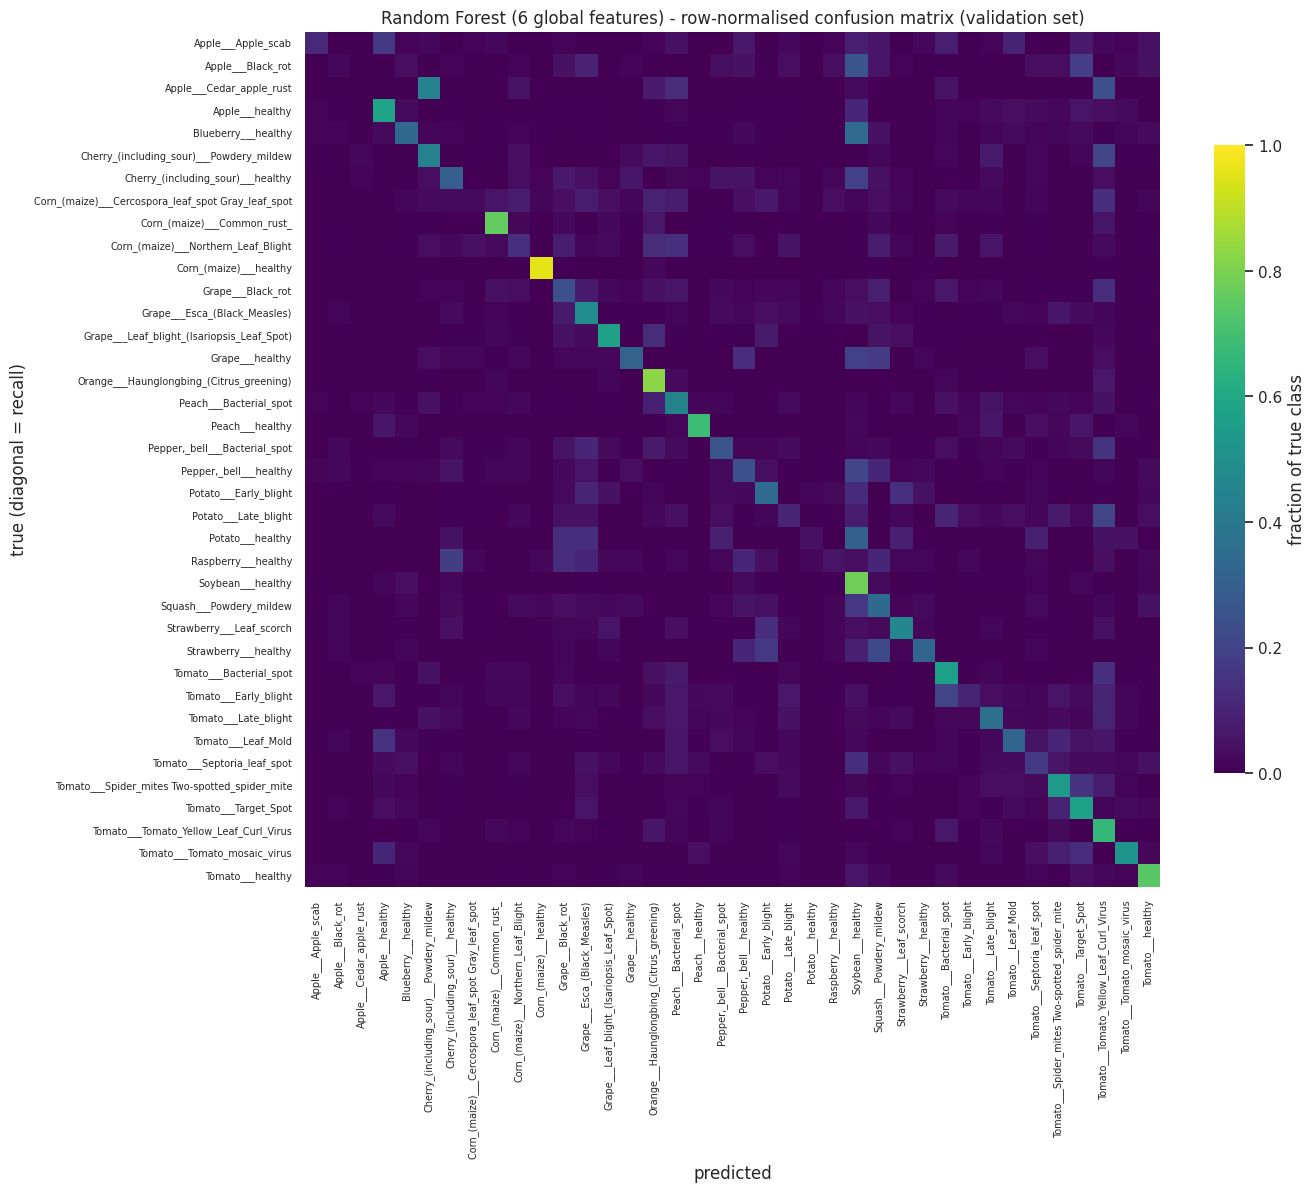

In [ ]:
# Confusion matrix, row-normalised so the diagonal reads as per-class recall
cm = confusion_matrix(yval, pred, labels=range(n_classes)).astype(float)
cm_norm = np.divide(cm, cm.sum(axis=1, keepdims=True),
                    out=np.zeros_like(cm), where=cm.sum(axis=1, keepdims=True) > 0)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, cmap="viridis", vmin=0, vmax=1, square=True,
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={"shrink": 0.7, "label": "fraction of true class"})
plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
plt.xlabel("predicted"); plt.ylabel("true (diagonal = recall)")
plt.title("Random Forest (6 global features) - row-normalised confusion matrix (validation set)")
plt.tight_layout(); plt.show()

## 8. Which of the six features does the forest lean on?

With only six inputs, the Gini importances are directly readable. Deliverable 1 showed these features collapse onto essentially one "lightness" dimension, so expect the forest to spread its (weak) signal across the brightness/colour-mean group — importance here reflects *which summaries the forest used*, not that they were sufficient.

**Why run it:** it makes the forest's (limited) reliance on each summary explicit.

**How it fits:** it connects the result back to Figures 3–4 — the features are redundant, so no single one carries separating power.

Feature importance (sums to 1):
file_size_kb    0.203
green_frac      0.180
mean_B          0.173
mean_R          0.169
mean_G          0.144
brightness      0.131


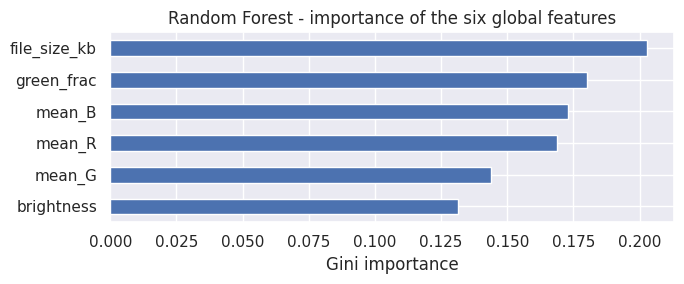

In [ ]:
# Per-feature Gini importance (only six features -> read them all)
imp = pd.Series(rf.feature_importances_, index=TAB_COLS).sort_values()
print("Feature importance (sums to 1):")
print(imp.sort_values(ascending=False).round(3).to_string())

plt.figure(figsize=(7, 3.0))
imp.plot(kind="barh", color="#4c72b0")
plt.xlabel("Gini importance"); plt.title("Random Forest - importance of the six global features")
plt.tight_layout(); plt.show()

## 9. Save the trained model

Persist the forest and its validation metrics so this result is reproducible and ready to fold into a combined classical-baseline comparison later.

In [ ]:
# Save the trained forest + its validation metrics
try:
    joblib.dump(rf, RF_DIR / "random_forest_global6.joblib")
    per_class.to_csv(RF_DIR / "rf_global6_per_class_recall.csv", index=False)
    imp.sort_values(ascending=False).to_csv(RF_DIR / "rf_global6_importance.csv", header=["importance"])
    with open(RF_DIR / "rf_global6_run_config.json", "w") as f:
        json.dump({"features": TAB_COLS, "n_features": len(TAB_COLS),
                   "n_estimators": N_ESTIMATORS, "rf_train_per_class": RF_TRAIN_PER_CLASS,
                   "seed": SEED, "n_train_fit": int(Xtr.shape[0]), "n_val": int(Xval.shape[0]),
                   "macro_F1": round(float(rf_mf1), 4), "accuracy": round(float(rf_acc), 4),
                   "smoke_test": SMOKE_TEST}, f, indent=2)
    print("Saved RF model + metrics to:", RF_DIR)
except Exception as e:
    print("Save skipped:", e)

Saved RF model + metrics to: /root/plant_recognition/step3_rf_global6


## 10. Reading the result

Read the forest's **validation macro-F1** next to the two baseline floors:

- If the Random Forest lands **near the dummy / LogReg floor**, that is the strong result for the report: a **non-linear** model on the **same six features** still cannot separate the classes, so the ceiling is the **features, not the model**. The six global summaries genuinely lack the disease signal — which is local and lesion-scale — and that is the clean empirical case for a pixel-reading CNN.
- If it lands **meaningfully above** the LogReg but still far below the CNN, that quantifies how much *non-linear* structure lives in these six summaries — modest at best, and still no substitute for reading the pixels.

Either way this is a **documentation floor in isolation**; placing it in a single table next to the Dummy, LogReg, and CNN is the next step, done separately. The **held-out test set stays sealed** — the honest final figure is reserved for Deliverable 2.

**Artifacts saved:** `random_forest_global6.joblib`, `rf_global6_per_class_recall.csv`, `rf_global6_importance.csv`, `rf_global6_run_config.json`, and the cached feature tables.